In [1]:
import sys
from pathlib import Path
import os

full_nb_path = os.path.abspath('')
PROJECT_ROOT = Path(full_nb_path).resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

In [2]:
# preliminary imports - may change based on final project naming conventions
# from src.helpers.helpers import load_single_image, load_text_for_image
# from src.cnn_module.model import load_cnn_model, predict_dish
from src.gan_module.inference import load_gan_generator, gan_predict_mask
from src.helpers.image_utils import (
    load_rgb_image,
    visualize_segmentation_result,
)
from src.autoencoder_module.model import build_autoencoder
from src.autoencoder_module.config import AEConfig
# from src.autoencoder_module.train import train_mask_ae_model, load_trained_ae_model # This gave an arror -AB
from src.nlp_module.model import load_nlp_model, evaluate_ingredients, generate_text
# from src.pipeline.app_pipeline import run_full_pipeline

## NLP - Flavor Predictor

In [3]:
# Input potential recipe ingredients
potential_recipes = [
    ['hamburger'],
    ['beef', 'lettuce', 'bun', 'mustard', 'ketchup']]

In [4]:
# Load models
text_model = load_nlp_model('../models/nlp_food_text_02.keras')
rating_model = load_nlp_model('../models/nlp_food_rating_02.keras')

In [6]:
for ingredients in potential_recipes:
    joined_ingredients = {', '.join(ingredients)}
    print(f'Evaluating: {joined_ingredients}')
    evaluate_ingredients(rating_model, ingredients)
    generate_text(text_model, ' '.join(ingredients))
    print('\n')

Evaluating: {'hamburger'}
Predicting for ['hamburger']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
I predict that ['hamburger'] will have a flavor level of: 5, Delicious!
I think it will taste like...
theralqurgllololulitiagem eloppac st cococae fraoxd spederasatipbok sz poder ns cadeaswrin zadesqura 

________________________________________________________________________________


Evaluating: {'beef, lettuce, bun, mustard, ketchup'}
Predicting for ['beef', 'lettuce', 'bun', 'mustard', 'ketchup']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
I predict that ['beef', 'lettuce', 'bun', 'mustard', 'ketchup'] will have a flavor level of: 5, Delicious!
I think it will taste like...
 y ceshebitj winas ar sige sarestioke  redlvedlippoube sos se meng teitit ricirlarcigrulotonkesalexp 

________________________________________________________________________________




## GAN

Found 4 test images

Processing burger_n_fries.jpg


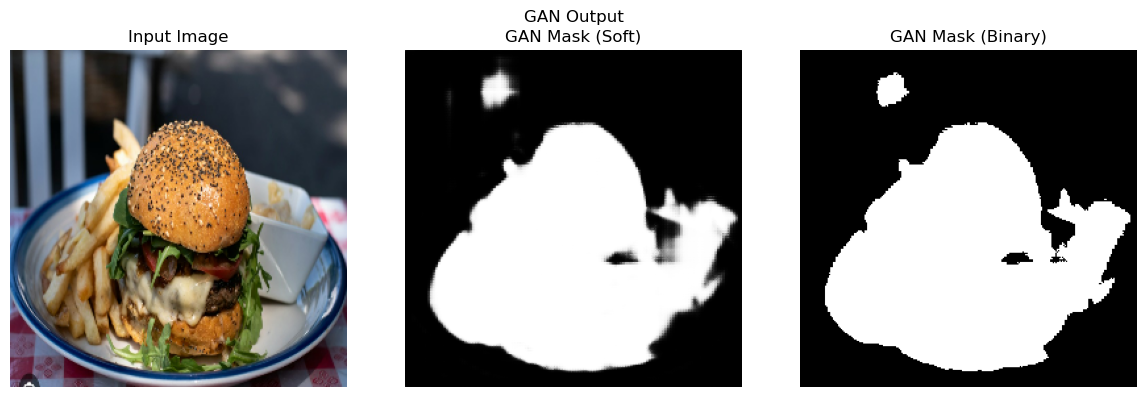


Processing fruit_basket.jpg


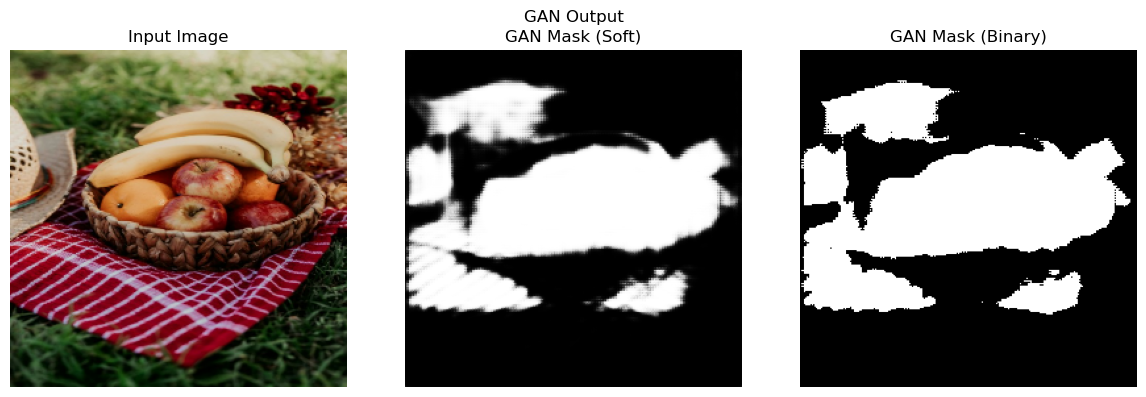


Processing pancakes.jpg


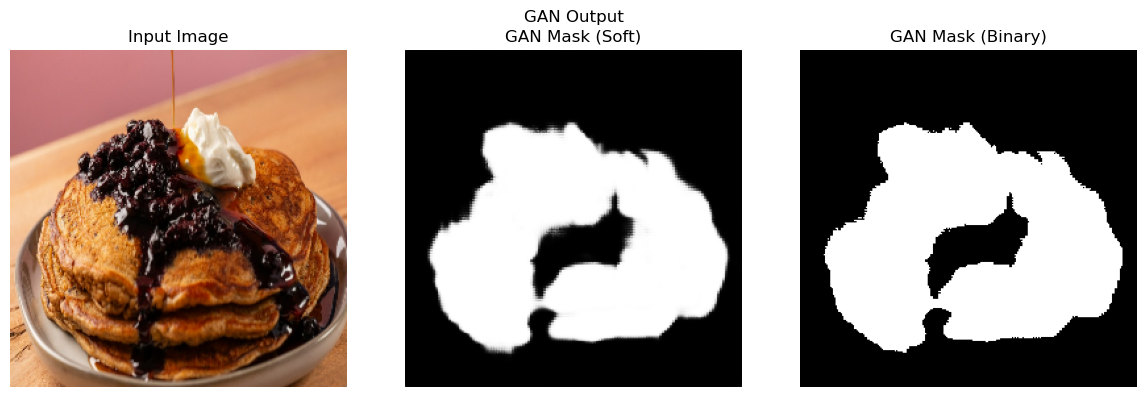


Processing salad_bowl.jpg


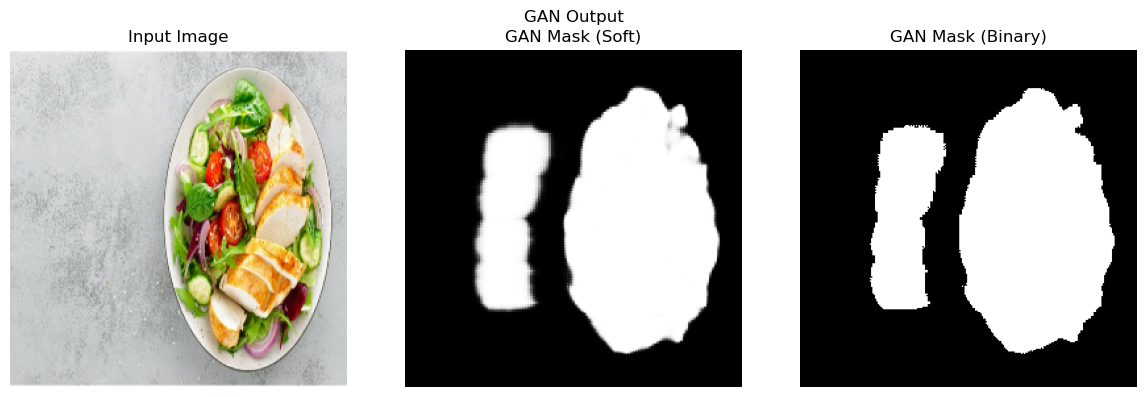

In [2]:
"""
Application pipeline entry point.

This file orchestrates:
- GAN segmentation
- (Autoencoder refinement – disabled for now)

During development, we can intercept and visualize intermediate outputs.
"""

import sys
from pathlib import Path

# ---------------------------------------------------------------------
# Add project root to PYTHONPATH
# ---------------------------------------------------------------------
# try:
#     PROJECT_ROOT = Path(__file__).resolve().parents[0]
# except NameError:
#     PROJECT_ROOT = Path.cwd().resolve()
# sys.path.insert(0, str(PROJECT_ROOT))

import tensorflow as tf
from src.gan_module.inference import load_gan_generator, gan_predict_mask
from src.helpers.image_utils import (
    load_rgb_image,
    visualize_segmentation_result,
)

# ---------------------------------------------------------------------
# Load models once
# ---------------------------------------------------------------------
GAN_MODEL_PATH = "../models/gan_generator.keras"
gan = load_gan_generator(GAN_MODEL_PATH)

# ---------------------------------------------------------------------
def run_gan_only(
    image: tf.Tensor,
    save_path: str = None,
    visualize: bool = True,
) -> tf.Tensor:
    """
    Run GAN only and optionally visualize/save output.

    Args:
        image: RGB image tensor (H, W, 3)
        save_path: where to save the visualization PNG
        visualize: whether to show/save visualization

    Returns:
        rough_mask: (256,256,1) float tensor
    """

    # ------------------------------------------------------------------
    # Resize image to GAN input resolution (must match gan_predict_mask)
    # ------------------------------------------------------------------
    resized_image = tf.image.resize(image, (256, 256))
    resized_image = tf.cast(resized_image, tf.uint8)

    rough_mask = gan_predict_mask(gan, resized_image)

    if visualize:
        visualize_segmentation_result(
            image=resized_image,   # <-- IMPORTANT CHANGE
            mask=rough_mask,
            threshold=0.5,
            title="GAN Output",
            save_path=save_path,
        )

    return rough_mask


# ---------------------------------------------------------------------
if __name__ == "__main__":
    IMAGE_DIR = PROJECT_ROOT / "test_images"
    image_paths = sorted(IMAGE_DIR.glob("*.jpg"))

    print(f"Found {len(image_paths)} test images")

    for img_path in image_paths:
        print(f"\nProcessing {img_path.name}")

        image = load_rgb_image(str(img_path))

        # Build output filename: original + _gan_only.png
        save_path = (
            img_path.with_suffix("").as_posix() + "_gan_only.png"
        )

        _ = run_gan_only(
            image=image,
            save_path=save_path,
            visualize=True,
        )

In [9]:
gan.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      3,136 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │    131,200 │ leaky_re_lu[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │    524,544 │ leaky_re_lu_1[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │  2,097,664 │ leaky_re_lu_2[0]… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      2,048 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 512) │  4,194,816 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 8, 8, 512) │          0 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │  4,194,816 │ re_lu[0][0]       │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      2,048 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 16,661,377 (63.56 MB)

 Trainable params: 16,657,537 (63.54 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [2]:
from pathlib import Path
import sys

def find_project_root(start: Path, marker: str = "src") -> Path:
    for p in [start] + list(start.parents):
        if (p / marker).exists():
            return p
    raise RuntimeError(f"Could not find project root containing '{marker}'")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

PROJECT_ROOT: C:\Users\missa\Repositories\CSB410_Deep_Learning\csb410_final
src exists: True


## Autoencoder

In [31]:
autoencoder = build_autoencoder(config=AEConfig())

In [69]:
# this cell is breaking in VS code and I am not able to get imports to work in Colab
# I will demo the further steps using the trained model with the dummy GAN mask function, but the intention
# is to run this cell, passing in the GAN mask function to train the autoencoder with our GAN masks

# ae_config = AEConfig()
# model, history = train_mask_ae_model(config=ae_config, gan_mask_function=gan_predict_mask)

In [70]:
AE_MODEL_PATH = "../models/best_mask_ae_model.keras"
autoencoder = load_trained_ae_model(AE_MODEL_PATH)

In [33]:
autoencoder.summary()

Model: "mask_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_1 (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_2 (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_3 (MaxPooling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Conv2D)             │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deconv_1 (Conv2DTranspose)      │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deconv_2 (Conv2DTranspose)      │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deconv_3 (Conv2DTranspose)      │ (None, 256, 256, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv2D)                 │ (None, 256, 256, 1)    │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,325,509 (8.87 MB)

 Trainable params: 775,169 (2.96 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,550,340 (5.91 MB)

### Autoencoder tensorboard results
![AE results](../data/AE-results-tb.png)

## CNN Food Classifier with Autoencoder Masks

In [57]:
# Load the CNN model
CNN_MODEL_PATH = "../models/cnn_food_classifier.keras"

# Get class names directly from Food101 dataset info
import tensorflow_datasets as tfds

# Load dataset info (no download, just metadata)
dataset_info = tfds.builder('food101').info
CLASS_NAMES = dataset_info.features['label'].names

print(f"Loaded {len(CLASS_NAMES)} class names from Food101 dataset")
print(f"Sample classes: {CLASS_NAMES[:10]}")

# Load the CNN model
from src.cnn_module.model import load_cnn_model
cnn_model = load_cnn_model(CNN_MODEL_PATH)
print(f"\nCNN model loaded from {CNN_MODEL_PATH}")

Loaded 101 class names from Food101 dataset
Sample classes: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']

CNN model loaded from ../models/cnn_food_classifier.keras


In [58]:
# Load the GAN generator for mask prediction
GAN_MODEL_PATH = "../models/gan_generator.keras"
gan_generator = load_gan_generator(GAN_MODEL_PATH)
print(f"GAN generator loaded from {GAN_MODEL_PATH}")

GAN generator loaded from ../models/gan_generator.keras


In [ ]:
def predict_food_with_refined_mask(image_path, cnn_model, gan_generator, autoencoder, class_names=None, img_size=224):
    """
    Complete pipeline: Load image -> GAN mask -> AE refinement -> CNN prediction
    
    Args:
        image_path: Path to food image file
        cnn_model: Trained CNN food classifier
        gan_generator: GAN model for initial mask generation
        autoencoder: Autoencoder for mask refinement
        class_names: List of food class names
        img_size: Image size for CNN (default 224 for EfficientNet)
    
    Returns:
        dict with prediction results and visualizations
    """
    import numpy as np
    import tensorflow as tf
    from src.helpers.image_utils import load_rgb_image
    from tensorflow.keras.applications.efficientnet import preprocess_input
    
    # Load the RGB image
    print(f"Loading image: {image_path}")
    rgb_image = load_rgb_image(image_path)
    
    # Generate initial mask using GAN (at 256x256)
    print("Generating initial mask with GAN...")
    gan_mask = gan_predict_mask(gan_generator, rgb_image, img_size=256)
    
    # Refine mask using Autoencoder
    print("Refining mask with Autoencoder...")
    refined_mask = autoencoder.predict(gan_mask[tf.newaxis, ...], verbose=0)[0]
    
    # Prepare display image (normalized [0, 1] for visualization)
    display_image = tf.image.resize(rgb_image, (img_size, img_size))
    display_image = tf.cast(display_image, tf.float32)
    if tf.reduce_max(display_image) > 1.5:
        display_image = display_image / 255.0
    
    # Prepare inputs for CNN (with EfficientNet preprocessing)
    print(f"Preparing inputs for CNN (resizing to {img_size}x{img_size})...")
    cnn_image = tf.image.resize(rgb_image, (img_size, img_size))
    cnn_image = tf.cast(cnn_image, tf.float32)
    # EfficientNet preprocessing expects [0, 255] range
    if tf.reduce_max(cnn_image) <= 1.5:
        cnn_image = cnn_image * 255.0
    cnn_image = preprocess_input(cnn_image)  # Apply EfficientNet-specific normalization
    
    # Resize refined mask to match CNN input size
    cnn_mask = tf.image.resize(refined_mask, (img_size, img_size))
    
    # Add batch dimension
    cnn_image_batch = cnn_image[tf.newaxis, ...]
    cnn_mask_batch = cnn_mask[tf.newaxis, ...]
    
    # Predict food class with CNN
    print("Predicting food class with CNN...")
    predictions = cnn_model.predict([cnn_image_batch, cnn_mask_batch], verbose=0)[0]
    
    # Get top prediction
    top_class_idx = np.argmax(predictions)
    top_confidence = predictions[top_class_idx]
    
    # Get top 5 predictions
    top_5_indices = np.argsort(predictions)[-5:][::-1]
    top_5_predictions = [
        {
            'class': class_names[idx] if class_names else f"Class {idx}",
            'confidence': float(predictions[idx])
        }
        for idx in top_5_indices
    ]
    
    result = {
        'predicted_class': class_names[top_class_idx] if class_names else f"Class {top_class_idx}",
        'confidence': float(top_confidence),
        'top_5': top_5_predictions,
        'image': display_image.numpy(),  # Store unaltered image for visualization
        'gan_mask': gan_mask.numpy(),
        'refined_mask': refined_mask,  # Already a numpy array from autoencoder.predict()
        'predictions_array': predictions
    }
    
    print(f"\nPrediction: {result['predicted_class']} (confidence: {result['confidence']:.2%})")
    
    return result

print("Prediction function defined: predict_food_with_refined_mask()")

Prediction function defined: predict_food_with_refined_mask()


In [ ]:
def visualize_prediction_pipeline(result, save_path=None):
    """
    Visualize the complete prediction pipeline with all intermediate steps.
    
    Args:
        result: Dictionary returned from predict_food_with_refined_mask()
        save_path: Optional path to save the visualization
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import tensorflow as tf
    
    fig = plt.figure(figsize=(20, 10))
    
    # Get image size for proper resizing
    img_height, img_width = result['image'].shape[:2]
    
    # Row 1: Image processing pipeline
    ax1 = plt.subplot(2, 4, 1)
    ax1.imshow(result['image'])
    ax1.set_title('Input Image', fontsize=12, fontweight='bold')
    ax1.axis('off')
    
    ax2 = plt.subplot(2, 4, 2)
    ax2.imshow(result['gan_mask'][..., 0], cmap='gray')
    ax2.set_title('GAN Mask (Raw)', fontsize=12, fontweight='bold')
    ax2.axis('off')
    
    ax3 = plt.subplot(2, 4, 3)
    ax3.imshow(result['refined_mask'][..., 0], cmap='gray')
    ax3.set_title('Refined Mask (AE)', fontsize=12, fontweight='bold')
    ax3.axis('off')
    
    # Overlay refined mask on image (resize mask to match image size)
    ax4 = plt.subplot(2, 4, 4)
    overlay = result['image'].copy()
    
    # Resize refined mask to match image dimensions
    refined_mask_resized = tf.image.resize(result['refined_mask'], (img_height, img_width)).numpy()
    mask_binary = (refined_mask_resized[..., 0] > 0.5).astype(np.float32)

    # Create colored mask overlay
    overlay_colored = overlay.copy()
    overlay_colored[:, :, 1] = np.clip(overlay_colored[:, :, 1] + mask_binary * 0.3, 0, 1)
    ax4.imshow(overlay_colored)
    ax4.set_title('Segmentation Overlay', fontsize=12, fontweight='bold')
    ax4.axis('off')
    
    # Row 2: Prediction results
    ax5 = plt.subplot(2, 4, 5)
    ax5.imshow(result['image'])
    prediction_text = f"{result['predicted_class']}\n{result['confidence']:.1%}"
    ax5.text(0.5, -0.15, prediction_text, 
             transform=ax5.transAxes,
             ha='center', va='top',
             fontsize=14, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    ax5.set_title('Final Prediction', fontsize=12, fontweight='bold')
    ax5.axis('off')
    
    # Top 5 predictions bar chart
    ax6 = plt.subplot(2, 4, (6, 7))
    top_5 = result['top_5']
    classes = [p['class'].replace('_', ' ').title() for p in top_5]
    confidences = [p['confidence'] for p in top_5]
    colors = ['green' if i == 0 else 'skyblue' for i in range(len(classes))]
    
    bars = ax6.barh(range(len(classes))[::-1], confidences, color=colors)
    ax6.set_yticks(range(len(classes))[::-1])
    ax6.set_yticklabels(classes)
    ax6.set_xlabel('Confidence', fontsize=11)
    ax6.set_title('Top 5 Predictions', fontsize=12, fontweight='bold')
    ax6.set_xlim([0, 1])
    
    # Add confidence values on bars
    for i, (bar, conf) in enumerate(zip(bars, confidences)):
        ax6.text(conf + 0.02, bar.get_y() + bar.get_height()/2, 
                f'{conf:.1%}', 
                va='center', fontsize=10)
    
    # Mask comparison (difference between GAN and refined) - resize both to same size for comparison
    ax8 = plt.subplot(2, 4, 8)
    gan_mask_resized = tf.image.resize(result['gan_mask'], result['refined_mask'].shape[:2]).numpy()
    mask_diff = np.abs(result['refined_mask'][..., 0] - gan_mask_resized[..., 0])
    im = ax8.imshow(mask_diff, cmap='hot')
    ax8.set_title('Mask Refinement\n(Difference)', fontsize=12, fontweight='bold')
    ax8.axis('off')
    plt.colorbar(im, ax=ax8, fraction=0.046, pad=0.04)
    
    plt.suptitle('CNN Food Classifier with GAN + Autoencoder Pipeline', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"Visualization saved to {save_path}")
    
    plt.show()

print("Visualization function defined: visualize_prediction_pipeline()")

Visualization function defined: visualize_prediction_pipeline()


### Example: Predict a food image

Loading image: C:/Users/dzcra/Documents/GitHub/csb410_final/test_images/burger_n_fries.jpg
Generating initial mask with GAN...
Refining mask with Autoencoder...
Preparing inputs for CNN (resizing to 224x224)...
Predicting food class with CNN...

Prediction: hamburger (confidence: 97.10%)
Visualization saved to ../data/prediction_result.png


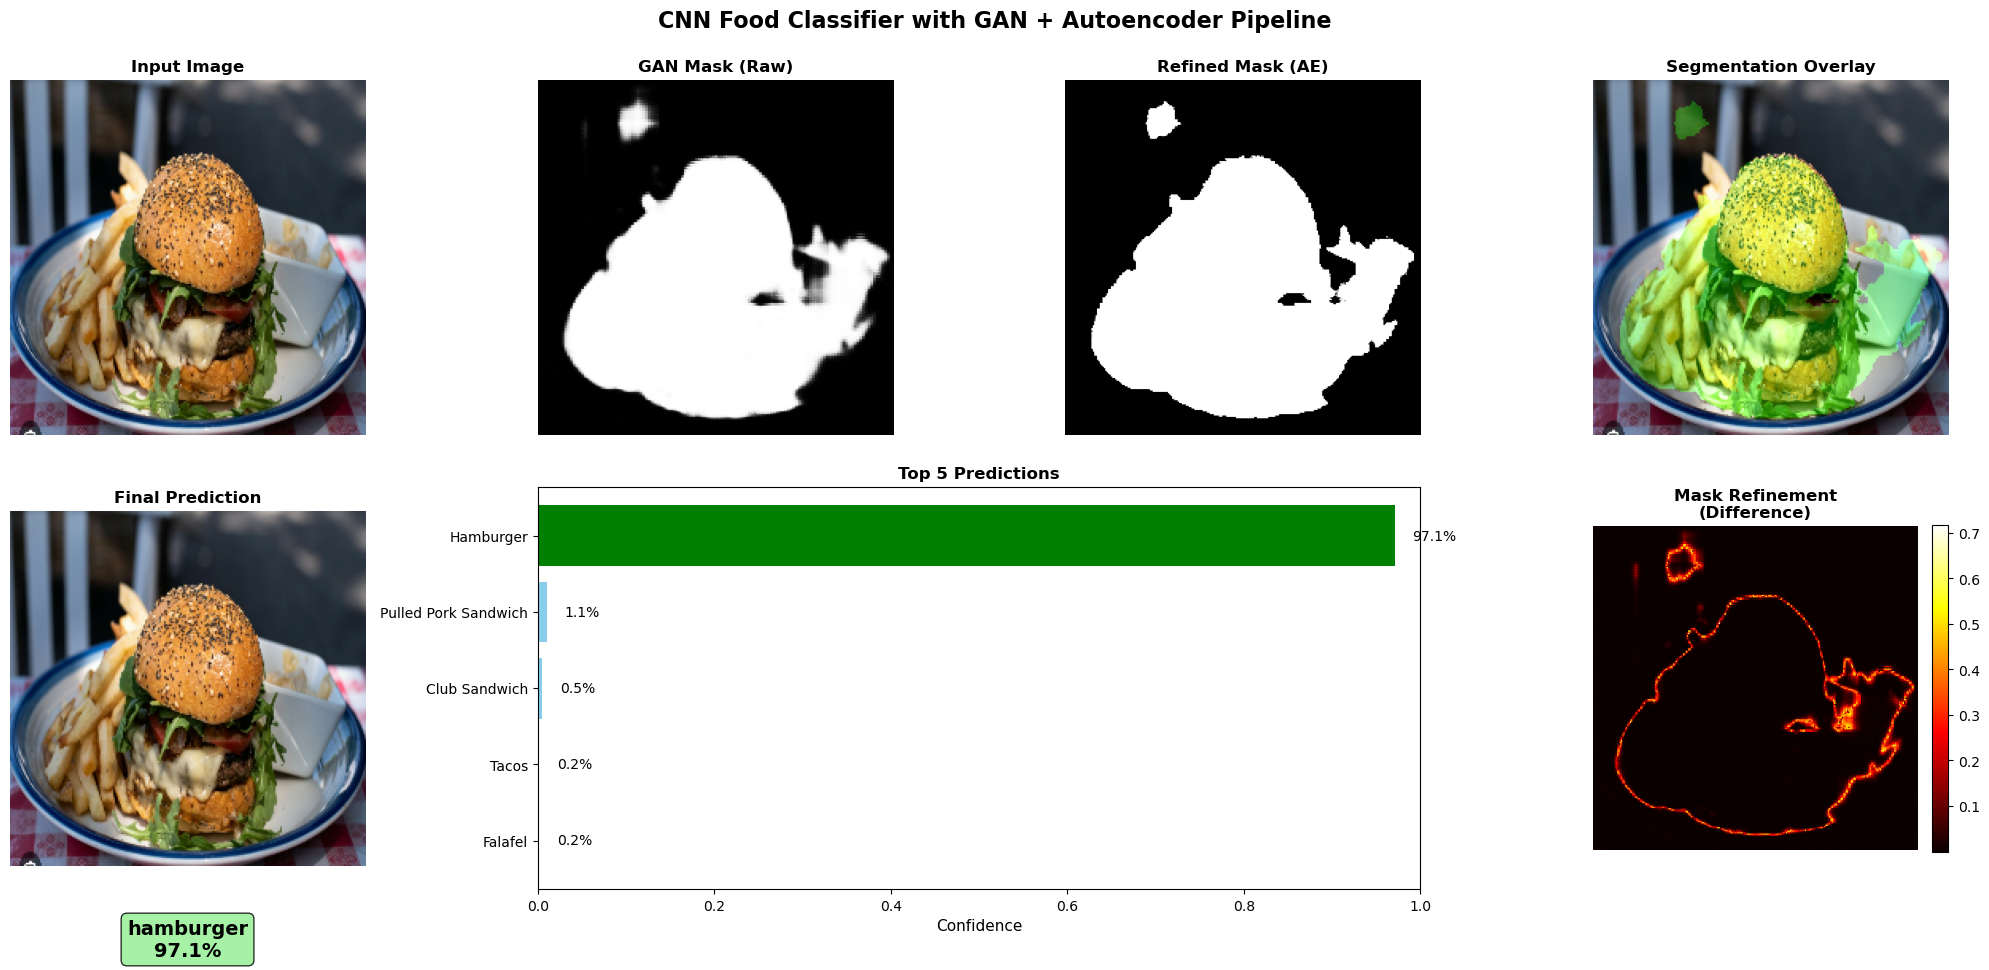


PREDICTION RESULTS
Predicted Class: hamburger
Confidence: 97.10%

Top 5 Predictions:
  1. hamburger                      - 97.10%
  2. pulled_pork_sandwich           - 1.08%
  3. club_sandwich                  - 0.54%
  4. tacos                          - 0.16%
  5. falafel                        - 0.15%


In [65]:
# Example usage
import tensorflow as tf
image_path = "C:/Users/dzcra/Documents/GitHub/csb410_final/test_images/burger_n_fries.jpg"

result = predict_food_with_refined_mask(
    image_path=image_path,
    cnn_model=cnn_model,
    gan_generator=gan_generator,
    autoencoder=autoencoder,
    class_names=CLASS_NAMES
)

# Visualize the complete pipeline
visualize_prediction_pipeline(result, save_path="../data/prediction_result.png")

# Print detailed results
print("\n" + "="*60)
print("PREDICTION RESULTS")
print("="*60)
print(f"Predicted Class: {result['predicted_class']}")
print(f"Confidence: {result['confidence']:.2%}")
print("\nTop 5 Predictions:")
for i, pred in enumerate(result['top_5'], 1):
    print(f"  {i}. {pred['class']:30s} - {pred['confidence']:.2%}")

### Comparison: With vs Without Autoencoder Refinement

This section demonstrates the impact of autoencoder mask refinement on prediction accuracy.

In [66]:
def compare_with_without_ae(image_path, cnn_model, gan_generator, autoencoder, class_names=None, img_size=224):
    """
    Compare CNN predictions using raw GAN mask vs AE-refined mask.
    
    Returns:
        dict with both predictions for comparison
    """
    import numpy as np
    from src.helpers.image_utils import load_rgb_image
    from tensorflow.keras.applications.efficientnet import preprocess_input
    
    # Load image
    rgb_image = load_rgb_image(image_path)
    
    # Prepare display image (normalized [0, 1] for visualization)
    display_image = tf.image.resize(rgb_image, (img_size, img_size))
    display_image = tf.cast(display_image, tf.float32)
    if tf.reduce_max(display_image) > 1.5:
        display_image = display_image / 255.0
    
    # Prepare CNN input (with EfficientNet preprocessing)
    cnn_image = tf.image.resize(rgb_image, (img_size, img_size))
    cnn_image = tf.cast(cnn_image, tf.float32)
    if tf.reduce_max(cnn_image) <= 1.5:
        cnn_image = cnn_image * 255.0
    cnn_image = preprocess_input(cnn_image)  # Apply EfficientNet-specific normalization
    
    # Generate GAN mask
    gan_mask = gan_predict_mask(gan_generator, rgb_image, img_size=256)
    
    # Prediction 1: Using raw GAN mask
    gan_mask_resized = tf.image.resize(gan_mask, (img_size, img_size))
    pred_gan = cnn_model.predict(
        [cnn_image[tf.newaxis, ...], gan_mask_resized[tf.newaxis, ...]], 
        verbose=0
    )[0]
    
    # Prediction 2: Using AE-refined mask
    refined_mask = autoencoder.predict(gan_mask[tf.newaxis, ...], verbose=0)[0]
    refined_mask_resized = tf.image.resize(refined_mask, (img_size, img_size))
    pred_refined = cnn_model.predict(
        [cnn_image[tf.newaxis, ...], refined_mask_resized[tf.newaxis, ...]], 
        verbose=0
    )[0]
    
    # Get top predictions for both
    top_gan = np.argmax(pred_gan)
    top_refined = np.argmax(pred_refined)
    
    result = {
        'image': display_image.numpy(),  # Store unaltered image for visualization
        'gan_mask': gan_mask.numpy(),
        'refined_mask': refined_mask,  # Already a numpy array from autoencoder.predict()
        'gan_prediction': {
            'class': class_names[top_gan] if class_names else f"Class {top_gan}",
            'confidence': float(pred_gan[top_gan])
        },
        'refined_prediction': {
            'class': class_names[top_refined] if class_names else f"Class {top_refined}",
            'confidence': float(pred_refined[top_refined])
        },
        'improvement': float(pred_refined[top_refined] - pred_gan[top_gan])
    }
    
    # Visualize comparison
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Row 1: Masks
    axes[0, 0].imshow(display_image.numpy())
    axes[0, 0].set_title('Input Image', fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(gan_mask.numpy()[..., 0], cmap='gray')
    axes[0, 1].set_title('GAN Mask (Raw)', fontweight='bold')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(refined_mask[..., 0], cmap='gray')  # refined_mask is already numpy
    axes[0, 2].set_title('AE Refined Mask', fontweight='bold')
    axes[0, 2].axis('off')
    
    # Row 2: Predictions
    axes[1, 0].imshow(display_image.numpy())
    axes[1, 0].set_title('Original Image', fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(display_image.numpy())
    pred_text = f"{result['gan_prediction']['class']}\\n{result['gan_prediction']['confidence']:.1%}"
    axes[1, 1].text(0.5, -0.15, pred_text, transform=axes[1, 1].transAxes,
                    ha='center', va='top', fontsize=11, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))
    axes[1, 1].set_title('Prediction (GAN Mask)', fontweight='bold')
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(display_image.numpy())
    pred_text = f"{result['refined_prediction']['class']}\\n{result['refined_prediction']['confidence']:.1%}"
    color = 'lightgreen' if result['improvement'] > 0 else 'lightyellow'
    axes[1, 2].text(0.5, -0.15, pred_text, transform=axes[1, 2].transAxes,
                    ha='center', va='top', fontsize=11, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor=color, alpha=0.8))
    axes[1, 2].set_title('Prediction (AE Refined)', fontweight='bold')
    axes[1, 2].axis('off')
    
    plt.suptitle('Impact of Autoencoder Mask Refinement on CNN Predictions', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\\n" + "="*60)
    print("COMPARISON RESULTS")
    print("="*60)
    print(f"Using GAN Mask:      {result['gan_prediction']['class']:30s} ({result['gan_prediction']['confidence']:.2%})")
    print(f"Using Refined Mask:  {result['refined_prediction']['class']:30s} ({result['refined_prediction']['confidence']:.2%})")
    print(f"Confidence Change:   {result['improvement']:+.2%}")
    print("="*60)
    
    return result

print("Comparison function defined: compare_with_without_ae()")

Comparison function defined: compare_with_without_ae()


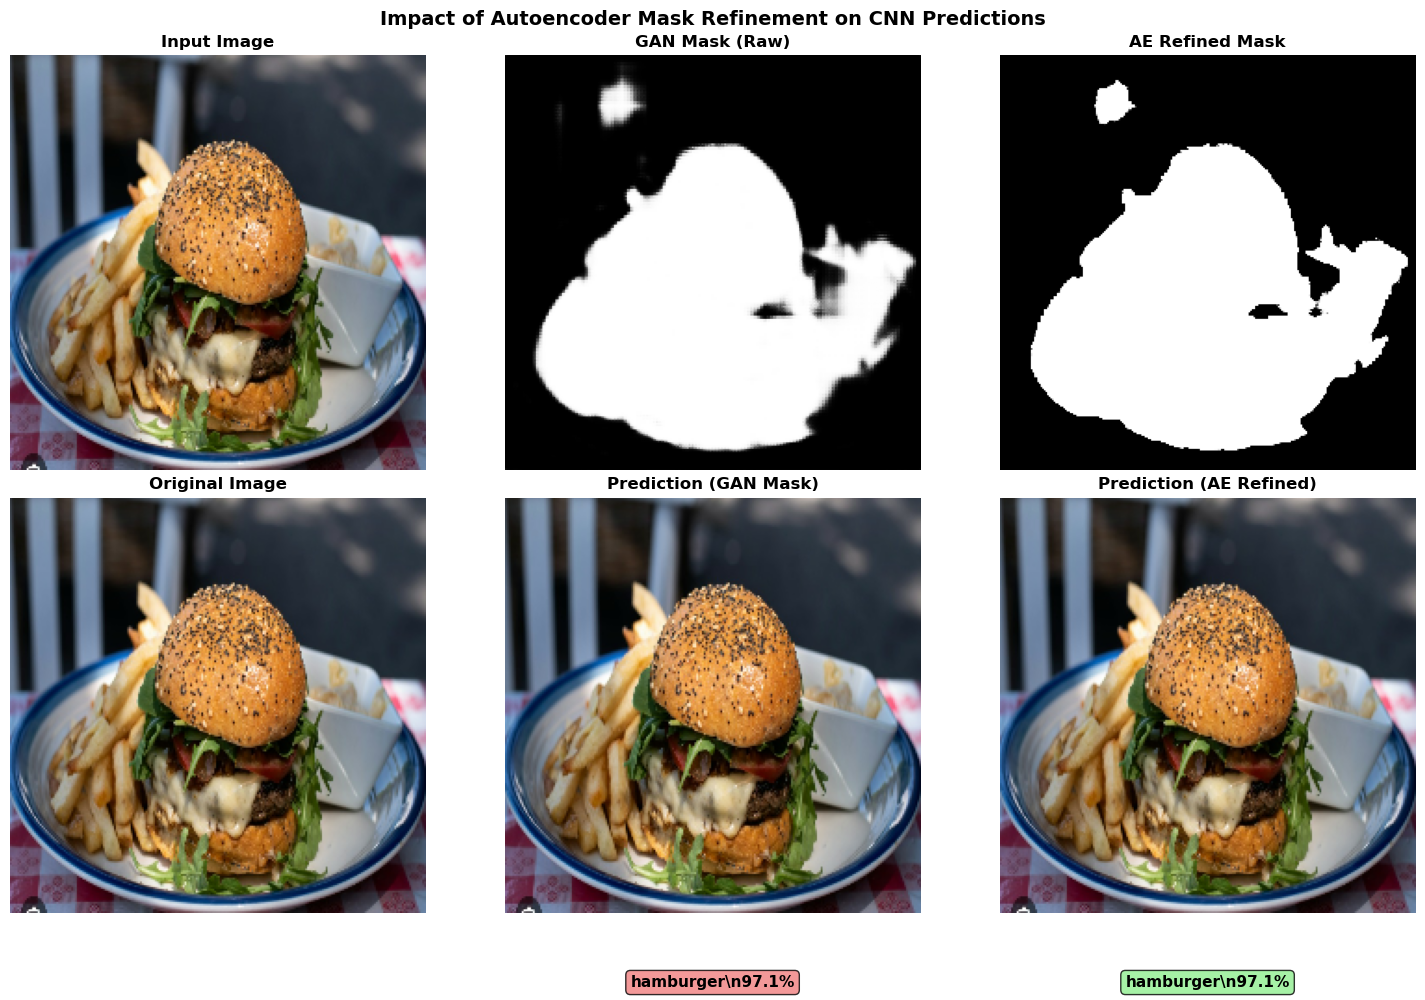

\n============================================================
COMPARISON RESULTS
Using GAN Mask:      hamburger                      (97.10%)
Using Refined Mask:  hamburger                      (97.10%)
Confidence Change:   +0.00%


In [67]:
# Example comparison
comparison_result = compare_with_without_ae(
    image_path=image_path,
    cnn_model=cnn_model,
    gan_generator=gan_generator,
    autoencoder=autoencoder,
    class_names=CLASS_NAMES
)